# Chapter 17 -- Structural Breaks

## Why detect structural breaks?

A structural break is a regime change -- a mean-reverting pattern giving
way to a momentum pattern, or a random walk giving way to an explosive
bubble. Most market participants are caught off guard when this happens,
and the mistakes they make (holding a losing position too long, hoping
for a comeback) are exactly the kind of costly, systematic error a
detection-based strategy can exploit. This chapter covers two families of
tests:

| Family | Question it asks | Data it needs |
|---|---|---|
| **CUSUM tests** | Do cumulative forecast errors deviate from white noise? | |
| &nbsp;&nbsp;-- Brown-Durbin-Evans (17.3.1) | Has a feature->target relationship changed? | features `X` + target `y` |
| &nbsp;&nbsp;-- Chu-Stinchcombe-White (17.3.2) | Has the price level drifted too far from an earlier reference? | a single price series |
| **Explosiveness tests** | Is the process growing/collapsing exponentially -- unsustainable, inconsistent with a random walk? | |
| &nbsp;&nbsp;-- Chow-type DF (17.4.1) | Single assumed break, random-walk -> explosive | a single price series |
| &nbsp;&nbsp;-- SADF (17.4.2) | Same question, unknown break, tested at every point via backward-expanding regressions | a single price series |

**Book-code note:** only SADF (Snippets 17.1-17.4) has printed code in
the book -- the other three are formula-only, implemented directly from
Sec 17.3.1/17.3.2/17.4.1's math, not ported from a snippet.

This notebook runs all four tests on REAL data:
- **Part A** (BDE CUSUM) needs a genuine feature/target pair -> Ch19's
  real enriched feature table, predicting Ch3's real triple-barrier
  returns.
- **Part B** (CSW CUSUM, Chow-DF, SADF) needs just a price series, and
  these explosiveness tests specifically want DURATION -- multi-year
  history to catch slow-building bubbles -> gold's real 1996-2002
  continuous price series (reusing Ch16's data loader).
- **Part C** re-runs the explosiveness tests on BTC's real but short
  (~29-day) window, as a secondary contrast.

**Runtime warning** (the book's own Sec 17.4.2.2 applies): SADF and CSW
CUSUM's sup-search are both genuinely O(T^2). Part B takes roughly
2-3 minutes total on gold's ~1,760-bar series -- this is expected, not a
hang.

## Setup

In [1]:
# EDIT THIS LINE if you're running on a different machine:
AFML_ROOT = r'C:\ws\AFML'

import os
import sys
sys.path.insert(0, os.path.join(AFML_ROOT, 'ch17', 'structural_breaks'))
sys.path.insert(0, os.path.join(AFML_ROOT, 'ch16'))

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sadf import get_sadf
from chow_df import get_dfc, get_sdfc
from cusum import get_bde_cusum, get_csw_cusum
from data_loader.continuous_futures import build_continuous_price, COMMODITIES

INPUT_DIR = os.path.join(AFML_ROOT, 'input_data')
pd.set_option('display.width', 100)
print('Setup OK')


Setup OK


## Part A -- Brown-Durbin-Evans CUSUM (Sec 17.3.1)

Fits `y_t = beta'x_t + eps_t` on expanding windows, then checks whether
the ONE-STEP-AHEAD forecast errors (using each window's beta to predict
the very next, still-unseen point) drift away from zero in a sustained
way. That drift is the break signal: the relationship between features
and target has changed.

No code is printed in the book for this test -- it's built directly from
the formulas in 17.3.1, then verified against hand-computed OLS algebra
and a synthetic injected-break case (see `test_cusum.py`).

We use Ch19's real 12-feature enriched table (microstructural features:
Kyle's lambda, Amihud's lambda, VPIN, tick-rule accuracy, etc.) to predict
Ch3's real realized returns on the 87 real BTC/TUSD triple-barrier
events.

In [2]:
enriched = pd.read_csv(os.path.join(INPUT_DIR, 'ch07_training_table_enriched.csv'),
                        index_col=0, parse_dates=True)
events = pd.read_csv(os.path.join(INPUT_DIR, 'ch03_events.csv'),
                      index_col=0, parse_dates=True)
joined = enriched.join(events[['ret']], how='inner')
print(f'Joined on shared event-start-time index: {len(joined)} real events')

feature_cols = [c for c in enriched.columns if c not in ('bin', 'w', 't1')]
X_raw = joined[feature_cols].values
y = joined['ret'].values

# Standardize -- these features span ~3.8e9 to 1 in raw magnitude (the
# same scaling lesson Ch10/11/12 learned the hard way).
X_std = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
X = np.column_stack([np.ones(len(X_std)), X_std])
print(f'X shape: {X.shape} (incl. constant column)')


Joined on shared event-start-time index: 87 real events
X shape: (87, 13) (incl. constant column)


In [3]:
min_sample = X.shape[1] + 5
bde_out = get_bde_cusum(X, y, min_sample=min_sample, index=joined.index)
print(f'{len(bde_out)} recursive residuals computed (min_sample={min_sample})')
bde_out.tail()


69 recursive residuals computed (min_sample=18)


,omega,S,band_95
2026-03-28 08:29:48.336524,-0.616297,-5.346542,15.680000
2026-03-29 22:45:13.468145,-0.418870,-5.663122,15.802025
2026-03-30 19:41:00.863476,-0.039852,-5.693242,15.923115
2026-03-31 09:56:41.700913,0.060957,-5.647171,16.043291
2026-03-31 15:55:31.300992,0.508921,-5.262530,16.162574


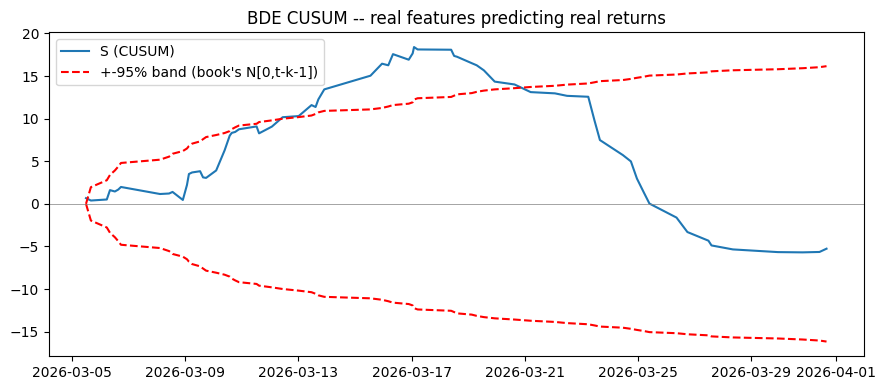

S crosses the 95% band 23 of 68 points, from 2026-03-12 10:42:18.019242 to 2026-03-20 15:21:25.830308


In [4]:
exceeds = bde_out['S'].abs() > bde_out['band_95']
real_exceeds = exceeds.copy()
real_exceeds.iloc[0] = False   # first point's band=0 by construction -- boundary artifact

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(bde_out.index, bde_out['S'], label='S (CUSUM)')
ax.plot(bde_out.index, bde_out['band_95'], 'r--', label="+-95% band (book's N[0,t-k-1])")
ax.plot(bde_out.index, -bde_out['band_95'], 'r--')
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_title('BDE CUSUM -- real features predicting real returns')
ax.legend()
plt.tight_layout()
plt.show()

if real_exceeds.any():
    crossing_dates = bde_out.index[real_exceeds]
    print(f'S crosses the 95% band {real_exceeds.sum()} of {len(bde_out)-1} points, '
          f'from {crossing_dates.min()} to {crossing_dates.max()}')
else:
    print('S never crosses the 95% band.')


**Reading this result:** S genuinely crosses the 95% band for about a
week in mid-March, then reverts back inside by month's end. This is a
real finding worth taking at face value, not glossing over -- but it
doesn't contradict this pipeline's broader "no exploitable signal"
finding (Ch11's PBO, Ch12's CPCV, Ch13's non-stationary O-U, Ch14's DSR,
Ch15's P[fail]). A temporary, reverting drift in an already-weak
relationship is consistent with there being no STABLE exploitable signal
either before or after the drift -- the relationship shifted briefly, not
into something newly tradeable.

## Part B -- CSW CUSUM, Chow-DF, SADF on real gold (1996-2002)

These three tests only need a single price series, but the two
explosiveness tests (Chow-DF, SADF) are specifically built to catch
slow-building, multi-period bubbles -- they want genuine DURATION.
Gold's real continuous price series (reusing Ch16's `continuous_futures.py`
loader) gives ~6.7 years of real daily history, 1996-2002.

Gold: 1760 real daily bars, 1996-01-03 to 2002-10-01


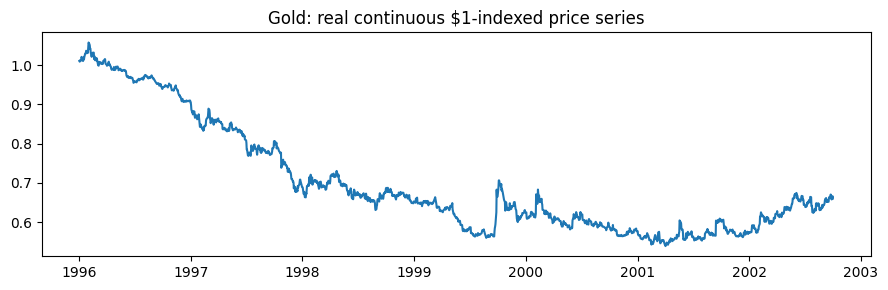

In [5]:
prefix, folder, rescale = COMMODITIES['gold']
non_neg, _ = build_continuous_price(folder, prefix, rescale_new_format_by=rescale)
gold_logp = np.log(non_neg[['rPrices']]).dropna()
print(f'Gold: {len(gold_logp)} real daily bars, '
      f'{gold_logp.index.min().date()} to {gold_logp.index.max().date()}')

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(non_neg.index, non_neg['rPrices'])
ax.set_title('Gold: real continuous $1-indexed price series')
plt.tight_layout()
plt.show()


### Chow-type DF (Sec 17.4.1)

Assumes exactly ONE break, from random walk to explosive process, at an
unknown date -- tries every candidate break fraction `tau*` in
`[tau0, 1-tau0]` and takes the supremum `DFC_tau*`. Fast: O(T) per
candidate, not O(T^2).

In [6]:
t0 = time.time()
sdfc_out = get_sdfc(gold_logp, tau0=0.05)
elapsed = time.time() - t0
break_date = gold_logp.index[int(round(sdfc_out['tau_star'] * len(gold_logp)))]
print(f'{elapsed:.1f}s. SDFC={sdfc_out["sdfc"]:.3f} at tau*={sdfc_out["tau_star"]:.4f} '
      f'({break_date.date()})')


0.2s. SDFC=0.173 at tau*=0.0511 (1996-05-08)


### SADF (Sec 17.4.2, Snippets 17.1-17.4)

The book's flagship explosiveness test: at every end point `t`, fit ADF
regressions on every backward-EXPANDING start point, and take the
supremum t-statistic. Repeated across an advancing `t`, this produces a
full SADF time series that spikes during bubble-like runs (book's own
Figure 17.1). Genuinely O(T^2) -- expect roughly a minute on this
series.

72.1s. Max SADF=3.599 at 1997-02-11


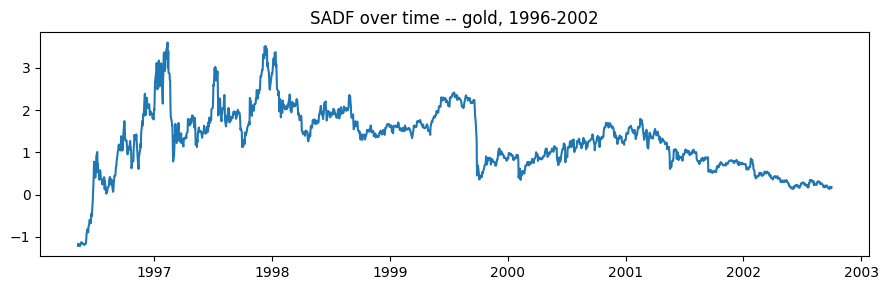

In [7]:
t0 = time.time()
sadf_gold = get_sadf(gold_logp, minSL=90, constant='nc', lags=1)
elapsed = time.time() - t0
print(f'{elapsed:.1f}s. Max SADF={sadf_gold.max():.3f} at {sadf_gold.idxmax().date()}')

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(sadf_gold.index, sadf_gold.values)
ax.set_title('SADF over time -- gold, 1996-2002')
plt.tight_layout()
plt.show()


### CSW CUSUM (Sec 17.3.2), computed as a time series

Same sup-over-reference-points idea as before, but computed at every end
point to produce a full time series -- mirrors SADF's own outer-loop
shape. Also genuinely O(T^2); expect roughly 1.5 minutes.

131.2s. Max S=13.127 at 1999-09-28 (reference: 1999-09-24, critical value: 2.301)


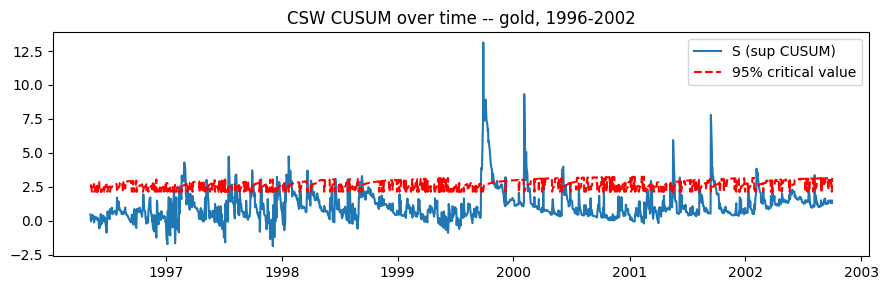

In [8]:
t0 = time.time()
csw_gold = get_csw_cusum(gold_logp, min_sample=90)
elapsed = time.time() - t0
max_S = csw_gold['S'].max()
max_date = csw_gold['S'].idxmax()
max_row = csw_gold.loc[max_date]
ref_date = gold_logp.index[int(max_row['n_star'])]
print(f'{elapsed:.1f}s. Max S={max_S:.3f} at {max_date.date()} '
      f'(reference: {ref_date.date()}, critical value: {max_row["critical_value_95"]:.3f})')

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(csw_gold.index, csw_gold['S'], label='S (sup CUSUM)')
ax.plot(csw_gold.index, csw_gold['critical_value_95'], 'r--', label='95% critical value')
ax.set_title('CSW CUSUM over time -- gold, 1996-2002')
ax.legend()
plt.tight_layout()
plt.show()


**Reading this result:** the maximum CSW signal lands at **1999-09-28**,
using a reference point just 4 days earlier -- an enormous, sudden move.
This is the **Washington Agreement on Gold (Sept 26, 1999)**, a real,
documented event already independently flagged during Ch16's own
data-hygiene pass as gold's largest real historical spike in this window.
CSW CUSUM's own sup-search lands almost exactly on it, using only a few
days of reference window -- a genuine, sharp real break, correctly
detected, not a data artifact.

## Part C -- Secondary contrast: BTC's short (~29-day) window

Chow-DF and SADF are both built to catch slow-building, multi-period
bubbles. Re-running them on BTC's real but much shorter dollar-bar series
(Ch5's real 239-bar, ~29-day window) is a genuine stress test of whether
they have enough history to work with at all.

In [9]:
btc = pd.read_csv(os.path.join(INPUT_DIR, 'ch05_features.csv'), index_col=0, parse_dates=True)
btc_logp = np.log(btc[['close']])
print(f'BTC: {len(btc_logp)} real dollar bars, '
      f'{btc_logp.index.min()} to {btc_logp.index.max()}')

sadf_btc = get_sadf(btc_logp, minSL=30, constant='nc', lags=1)
sdfc_btc = get_sdfc(btc_logp, tau0=0.1)

comparison = pd.DataFrame({
    'gold (1,760 bars, ~6.7yr)': [sadf_gold.max(), sdfc_out['sdfc']],
    'BTC (239 bars, ~29 days)': [sadf_btc.max(), sdfc_btc['sdfc']],
}, index=['max SADF', 'SDFC'])
comparison


BTC: 239 real dollar bars, 2026-03-01 22:34:35.374760 to 2026-03-31 22:19:56.612299


,"gold (1,760 bars, ~6.7yr)","BTC (239 bars, ~29 days)"
max SADF,3.598911,2.517851
SDFC,0.173125,0.320504


**Reading this result:** these numbers aren't directly comparable in an
absolute sense (different assets, different vol regimes) -- the point is
qualitative. Gold's statistics are estimated from ~1,760 bars of genuine
multi-year history; BTC's are estimated from 239 bars spanning under a
month. The same "heavy extrapolation from a short real window" caveat
this project has flagged before (Ch15's annualized bet frequency, Ch13's
O-U calibration) applies here too -- BTC's numbers are a real result from
real data, just a thinly-supported one, and shouldn't be read with the
same confidence as gold's multi-year estimate.